In [1]:
import importlib
import matplotlib.pyplot as plt
import numpy as np

from lust_codesnippets_py.astronomy import bazin_model

importlib.reload(bazin_model)

<module 'lust_codesnippets_py.astronomy.bazin_model' from '/home/lukas/github/LuStCodeSnippets/lust_codesnippets_py/astronomy/bazin_model.py'>

/home/lukas/github/LuStCodeSnippets/lust_codesnippets_py/astronomy/bazin_model.py:189: RuntimeWarning: invalid value encountered in log
  t_peak = t0 + tau_rise*np.log(tau_fall/tau_rise - 1)


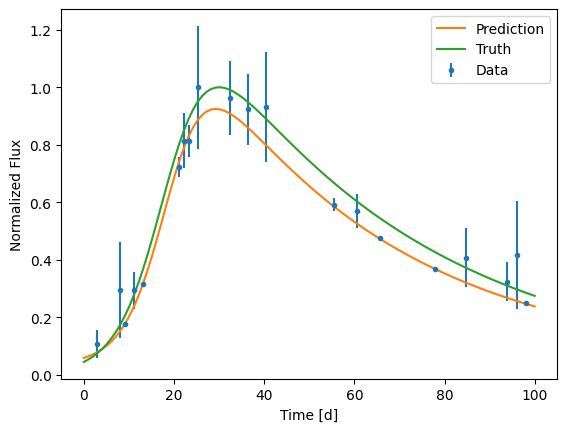

In [2]:
#ground truth
B2011 = bazin_model.Bazin2011(0, 20, 50, 5, None, 30)
x_true = np.linspace(0,100,100)
y_true = B2011.predict(x_true)
y_true /= y_true.max()

#simulate observations
ridxs = np.random.permutation(np.arange(len(x_true)))[:20]  #random subset of observations
x = x_true[ridxs]
y = y_true[ridxs]
y_e = 0.1*np.abs(np.random.normal(size=x.shape))
y +=  y_e/y_true.max()
y /= y.max()

#fitting a predictor
x_pred = np.linspace(0,100,100)
BM = bazin_model.BazinModel()
BM.fit(x, y, y_e)
y_pred = BM.predict(x_pred)

#plotting result
fig, axs = plt.subplots(1,1, subplot_kw=dict(xlabel="Time [d]", ylabel="Normalized Flux"))
axs.errorbar(x, y, yerr=y_e, ls="", marker=".", label="Data")
axs.plot(x_pred, y_pred, label="Prediction")
axs.plot(x_true, y_true, label="Truth")
axs.legend()
plt.show()